![bse_logo_textminingcourse](https://bse.eu/sites/default/files/bse_logo_small.png)

# Introduction to Text Mining and Natural Language Processing

## Text Classification Application

From our paper: How Big is the Media Multiplier? Evidence from Dyadic News Data

(joint work with Tim Besley and Thiemo Fetzer)

https://drive.google.com/file/d/1SfUUzkZZs5OMWu3QY2uxWfjsimGjj1tf/view?usp=sharing

If you use pieces of the machinery developed here we would, of course, be happy about citation. Published version of the paper is here https://doi.org/10.1162/rest_a_01415.

### Pre-processing Review

Before we start we will do some pre-processing with a small subset of the data to review this again.

First let's load the raw article data. These are 200 articles from Egypt and Turkey.

In [16]:
#! pip install graphviz
# graphviz will generate problems. Read instructions for your system! For my MAC I did a conda install and it worked.

import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from pprint import pprint

from time import time

from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score

# path to where you saved the training dataset that I provided
readin = 'C:\\Users\\sffra\\Downloads\\BSE 2025-2026\\nlp\\s8'

spitout= 'C:\\Users\\sffra\\Downloads\\BSE 2025-2026\\nlp\\s8'


#this is loading training dataset
filename ="200articles.csv"
# loading the training data
data_train = pd.read_csv(os.path.join(readin, filename), sep=',', encoding='utf-8')
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     200 non-null    int64  
 1   ARTICLENUMID   200 non-null    object 
 2   LENGTH         200 non-null    object 
 3   year           200 non-null    float64
 4   day            174 non-null    float64
 5   monthnum       200 non-null    float64
 6   issuing_iso3c  200 non-null    object 
 7   dest_iso3c     200 non-null    object 
 8   TXT_EN         200 non-null    object 
 9   label_0        33 non-null     float64
 10  label_1        25 non-null     float64
 11  label_2        25 non-null     float64
 12  label_3        25 non-null     float64
 13  TITLE_EN       200 non-null    object 
dtypes: float64(7), int64(1), object(6)
memory usage: 22.0+ KB


## Exercise

Focus on columns TXT_EN and TITLE_EN. These two columns contain the text and the title of the article. TXT_EN has, in fact both the text and the title as can be seen here:

In [17]:
print("Title:", data_train.TITLE_EN[0])
print("   ")
print("Text:", data_train.TXT_EN[0])

Title: Israeli PM's office denies pending prisoner release over captured soldier
   
Text: Israeli PM's office denies pending prisoner release over captured soldier
The Israeli Prime Minister's  Office (PMO) on Thursday denied reports that a deal is in the  works between Israel, Egypt and Hamas to gain the release of a  kidnapped soldier, being held in Gaza.  
Meanwhile, both Hamas and Egyptian officials, including  Muhammad Bassiouni, Cairo's former ambassador to Israel, also  hastily denied that any agreement was in the works, according to  Israel Radio.
The PMO release comes in the wake of statements by Muhammad  Bassiouni, Cairo's former ambassador to Israel, to a local  newspaper that Hamas would release Gilad Shalit, captured from a  border post along the Gaza border over five years ago, "within  hours," in return for Israel freeing some 1,000 security  prisoners.
Israeli Defense Ministry official Amos Gilad on Wednesday  traveled to Cairo for talks with officials on a number of 

Answer all these questions alone. You can obviously copy paste from other parts of the course (some things are below). But do not help your classmates and do not exchange code.

1) Think about how you would pre-process the TEXT_EN data. Treat every text as one document. Remove punctuation and digits, remove stop-words and lemmatize. I will give the result of what I did below. Note that I pre-processed and then I did a train/test split and I am just giving you the train data.

2) Count-vectorize and generate the document-term matrix including unigrams and bigrams. Keep the default setting of the sklearn count vectorizer. What dimensions has the document-term matrix? What are these dimensions? 

3) If you would not stem, would you expect higher or lower dimensions for the document term matrix?

4) Implement different cutoffs for the lower-bound document frequency and a upper-bound document frequency - keep track of how the vocabulary size changes with different cutoffs.

5) Write down what cutoffs you would choose and why (there is no right and wrong answer here).

6) Implement the following idea: pre-process the TITLE_EN, count-vectorize TITLE_EN with the count vectorizer from 4). Add the counts such that the titles receive 5 times the weight as the rest of the text.

In [18]:
filename ="training_set.csv"
data_train = pd.read_csv(os.path.join(readin, filename), sep=',', encoding='utf-8')
data_train=data_train.dropna(subset='text_preproc')
data_train.info()

print("")
print("Pre-processed Headlines")
for article in data_train.titles_preproc[:1]:
    print(article)
print("")
print("Pre-processed Texts")
for article in data_train.text_preproc[:1]:
    print(article)

<class 'pandas.core.frame.DataFrame'>
Index: 11752 entries, 0 to 11757
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      11752 non-null  int64  
 1   TITLE_EN        11752 non-null  object 
 2   TXT_EN          11752 non-null  object 
 3   text_preproc    11752 non-null  object 
 4   titles_preproc  11752 non-null  object 
 5   dest_iso3c      11752 non-null  object 
 6   day             11752 non-null  float64
 7   monthnum        11752 non-null  float64
 8   year            11752 non-null  float64
 9   label_0         11752 non-null  float64
 10  label_1         11752 non-null  float64
 11  label_2         11752 non-null  float64
 12  label_3         11752 non-null  float64
dtypes: float64(7), int64(1), object(5)
memory usage: 1.3+ MB

Pre-processed Headlines
343 kill Egypt clash Interior Ministry

Pre-processed Texts
343 kill Egypt clash Interior Ministry 343 people kill Egypt clash support

# Supervised Learning

Let's start with some useful functions. These will be used later. I recommend you to keep these around as they are extremely handy functions to have at hand when playing around with data. There are also some text processing functions here useful for the task above.

In [19]:

#additional functions

#the following leaves in place two or more capital letters in a row
#will be ignored when using standard stemming

#Functions to make figures and save them
def draw_precision_curve(y,x,name):
    precision, recall, thresholds = precision_recall_curve(y, x)
    avprec=average_precision_score(y, x)

    plt.plot(recall, precision, lw=5, label='Av.Precision = %0.2f)' % (avprec))

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision/Recall Curve')
    plt.legend(loc="lower left")
    plt.savefig(spitout+name+'.pdf')
    plt.show()

def draw_roc_curve(y,x,name):
    fpr, tpr, thresholds = roc_curve(y,x)
    roc_auc = auc(fpr, tpr)


    plt.plot(fpr,tpr, lw=5, label='AUC = %0.2f)' % (roc_auc))

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower left")
    plt.savefig(spitout+name+'.pdf')
    plt.show()
    
    
def separation_plot(pdata, fname, alpha=1):
    '''
    Display observed events against predicted probabilities for binary classification problems
    Arguments
    ---------
        y_true : vector of observed class labels
        y_pred : vector of predicted probabilities
        fname: file path to directory to save plot 
        alpha: float from 0 to 1, transparency of indicators of observed events
    '''
    #normalization
    pdata=(pdata-pdata.min())/(pdata.max()-pdata.min())
    
    #wrangling
    pdata.columns = ['y', 'yhat']
    pdata = pdata.sort_values('yhat')
    pdata = pdata.reset_index(drop=True)

    events = pdata[pdata['y'] == 1]

    evals = events.index.values


    plt.figure(figsize=(20, 5))
    plt.ylabel('Predicted Score')
    ax = plt.gca()
    ax.set_xlim([1, (evals[-1] + 1)])
    ax.set_ylim([0, 1])
    

    rr = 0
    for i in evals:
        if rr == 0:
            ax.axvline(x=i, linewidth=0.2, linestyle='-', color='k', alpha=alpha, label = 'True Positives', zorder=2)
            rr = 1
        else:
            ax.axvline(x=i, linewidth=0.2, linestyle='-', color='k', alpha=alpha, zorder=1)
    
    ax.plot(pdata['yhat'], linestyle='--', color='red', lw = 4, label = 'Predicted Score', zorder=3)
    ax.set_xlabel('Rank of prediction')
    ax.legend(loc="upper left")
    plt.savefig(fname)
    plt.show()
    plt.close() 

In [20]:
Titles = data_train.titles_preproc.tolist()
Texts = data_train.text_preproc.tolist()

# get labels to list
labels_1 = data_train.label_1.tolist()
labels_2 = data_train.label_2.tolist()




In [21]:
print(Texts[:1])
print("Entire training text data has length", len(Texts))
#this is the headline and the body of the first article after cleaning. You see how I did not do this perfectly

['343 kill Egypt clash Interior Ministry 343 people kill Egypt clash supporter oust President Mohamed Morsi security troop disperse Wednesday pro morsi sit site country Interior Ministry say Thursday egyptian security force start Wednesday dawn cleaning operation Rabaa al Adawiya Square Cairo Nasr City Nahda Square Giza pro morsi protester sit 45 day']
Entire training text data has length 11752


In [22]:
#battery of count vectorizers
#feel free to play with this (will repeat further below)


cv = CountVectorizer(ngram_range = (1,2))
cv.fit(Texts)
vectorized_text=cv.transform(Texts)
names=np.array(cv.get_feature_names_out())
print("dimensions of DT matrix are", vectorized_text.shape)

cv = CountVectorizer(ngram_range = (1,2), min_df=0.001)
cv.fit(Texts)
vectorized_text=cv.transform(Texts)
vectorized_titles=cv.transform(Titles)
#what am I doing here below?
overall=vectorized_text+4*vectorized_titles
names=np.array(cv.get_feature_names_out())
print("with mindf dimensions of DT matrix are", vectorized_text.shape)

dimensions of DT matrix are (11752, 530158)
with mindf dimensions of DT matrix are (11752, 16291)


# Random Forest with Text Fast Intro

I find the random forest classifier extremely useful in applications with text. It is robust, hard to overfit and flexible. So my recommendation is to try Random Forests first if you are doing some text classification task.

In [23]:
from sklearn.ensemble import RandomForestClassifier

clf_text = RandomForestClassifier(300, max_depth=1, class_weight ="balanced")
clf_text.fit(vectorized_text,labels_2)

importances = clf_text.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf_text.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]

Feature ranking illustration:


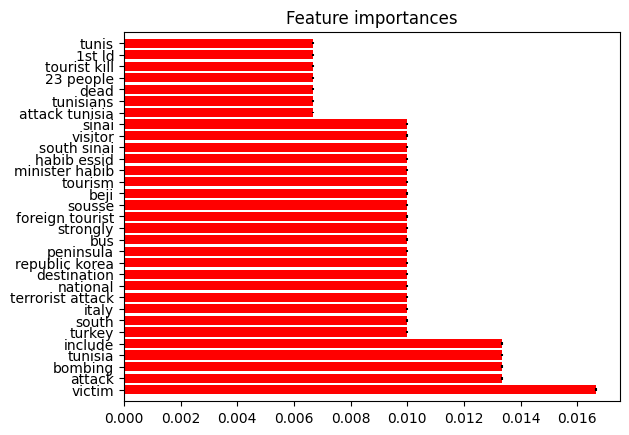

In [24]:
# Print the feature ranking
print("Feature ranking illustration:")

#show top thirty only
#imp_range=X.shape[1]
imp_range=31
indices_top=indices[0:imp_range]
#for f in range(imp_range):
#    print("%d. feature %d (%f)" % (f + 1, indices_top[f], importances[indices_top[f]]))

plt.figure()
plt.title("Feature importances")
plt.barh(range(imp_range), importances[indices_top],
       color="r", yerr=std[indices_top], align="center")
plt.yticks(range(imp_range), names[indices_top])
plt.ylim([-1, imp_range])
plt.show()

dot exists: True
which dot: C:\Program Files\Graphviz\bin\dot.EXE
DOT_BINARY: C:\Program Files\Graphviz\bin\dot.exe


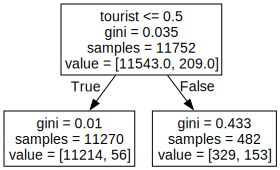

In [25]:
import os, shutil
import graphviz.backend.dot_command as dc

dot = r"C:\Program Files\Graphviz\bin\dot.exe"
os.environ["PATH"] = r"C:\Program Files\Graphviz\bin;" + os.environ["PATH"]
dc.DOT_BINARY = dot

print("dot exists:", os.path.exists(dot))
print("which dot:", shutil.which("dot"))
print("DOT_BINARY:", dc.DOT_BINARY)

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

clf = DecisionTreeClassifier(max_depth=1, random_state=1000)
clf = clf.fit(vectorized_text,labels_2)

dot_data = export_graphviz(clf, out_file=None, feature_names=names)
graph = graphviz.Source(dot_data)
graph.render("exampletree1")
graph


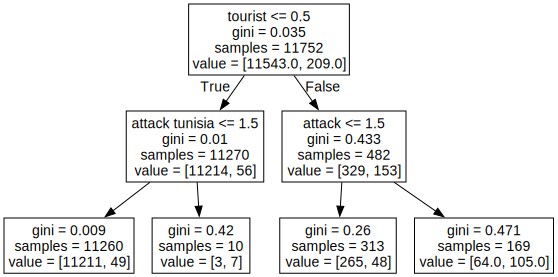

In [26]:
clf = DecisionTreeClassifier(max_depth=2, random_state=1000)
clf = clf.fit(vectorized_text,labels_2)

dot_data = export_graphviz(clf, out_file=None, feature_names=names)
graph = graphviz.Source(dot_data)
graph.render("exampletree2")
graph

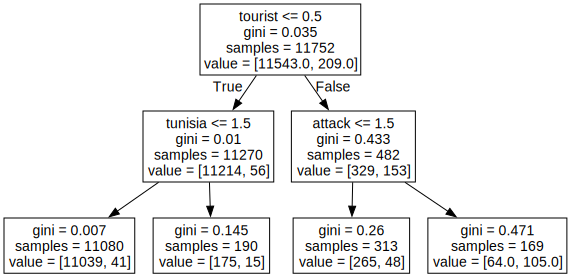

In [27]:
clf = DecisionTreeClassifier(max_depth=2, random_state=1000, min_samples_leaf=100)
clf = clf.fit(vectorized_text,labels_2)

dot_data = export_graphviz(clf, out_file=None, feature_names=names)
graph = graphviz.Source(dot_data)
graph.render("exampletree2_minleaf")
graph

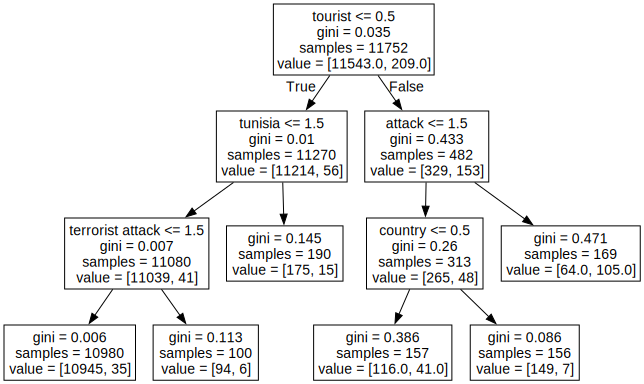

In [28]:
clf = DecisionTreeClassifier(max_depth=3, random_state=1000, min_samples_leaf=100)
clf = clf.fit(vectorized_text,labels_2)

dot_data = export_graphviz(clf, out_file=None, feature_names=names)
graph = graphviz.Source(dot_data)
graph.render("exampletree3_minleaf")
graph


What would you do if you saw this and you wanted to develop a general methodology to spot violence against tourists?

# Pipeline from our project


In [29]:
pipeline = Pipeline(
    [
        ("vect", CountVectorizer()),
        ("tfidf", TfidfTransformer()),
        ("clf", RandomForestClassifier()),
    ]
)

parameters = {
    "vect__max_df": (0.3,0.4),
    "vect__min_df": ([0.008]),
    "vect__ngram_range": ([(1,1)]),  # unigrams or bigrams
    "tfidf__use_idf": ([True]),
    'tfidf__norm': (['l1']),
    "clf__max_depth": ([20]),
    "clf__n_estimators": ([300]),
    "clf__min_samples_leaf": ([10]),
    "clf__class_weight": (["balanced"]),
}

# Find the best parameters for both the feature extraction and the
# classifier
grid_search = GridSearchCV(pipeline, parameters, n_jobs=4, verbose=3, scoring='roc_auc', cv=3)

print("Performing grid search...")
print("pipeline:", [name for name, _ in pipeline.steps])
print("parameters:")
pprint(parameters)
t0 = time()
grid_search.fit(Texts, labels_1)
print("done in %0.3fs" % (time() - t0))
print()

print("Best score: %0.3f" % grid_search.best_score_)
print("Best parameters set for label 1:")
best_parameters = grid_search.best_estimator_.get_params()
for param_name in sorted(parameters.keys()):
    print("\t%s: %r" % (param_name, best_parameters[param_name]))

Performing grid search...
pipeline: ['vect', 'tfidf', 'clf']
parameters:
{'clf__class_weight': ['balanced'],
 'clf__max_depth': [20],
 'clf__min_samples_leaf': [10],
 'clf__n_estimators': [300],
 'tfidf__norm': ['l1'],
 'tfidf__use_idf': [True],
 'vect__max_df': (0.3, 0.4),
 'vect__min_df': [0.008],
 'vect__ngram_range': [(1, 1)]}
Fitting 3 folds for each of 2 candidates, totalling 6 fits
done in 23.376s

Best score: 0.942
Best parameters set for label 1:
	clf__class_weight: 'balanced'
	clf__max_depth: 20
	clf__min_samples_leaf: 10
	clf__n_estimators: 300
	tfidf__norm: 'l1'
	tfidf__use_idf: True
	vect__max_df: 0.4
	vect__min_df: 0.008
	vect__ngram_range: (1, 1)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   3 | elapsed:    5.1s finished


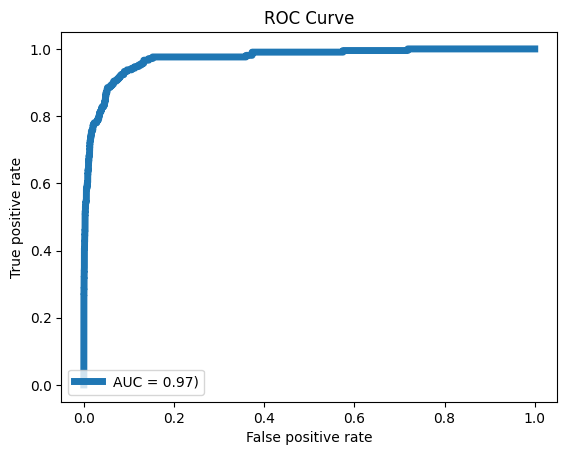

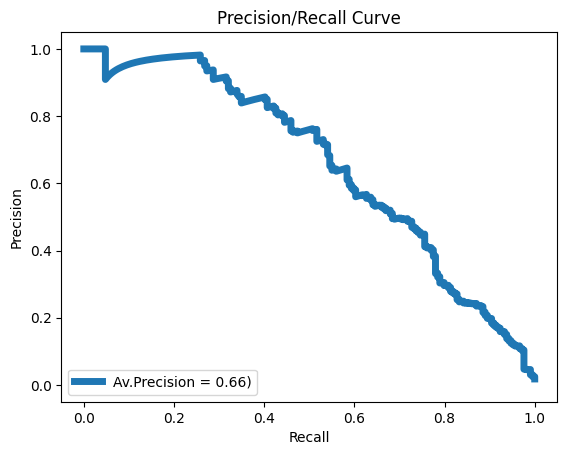

In [30]:
clf_rf2 = grid_search.best_estimator_
y_pred_rf2 = cross_val_predict(clf_rf2, Texts, labels_2, n_jobs=4, verbose=2, cv=3, method= 'predict_proba')[:,1]

draw_roc_curve(labels_2, y_pred_rf2 ,"ml_rf_tourist_harm_roc_curve")

draw_precision_curve(labels_2, y_pred_rf2 ,"ml_rf_tourist_harm_precision_curve")

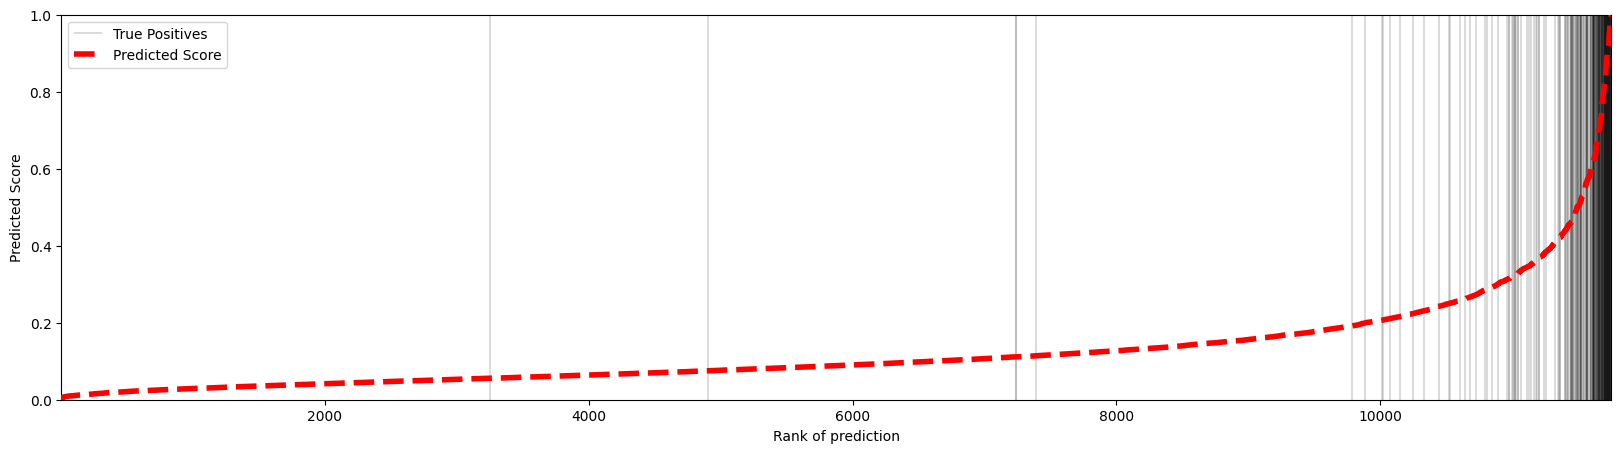

In [31]:
data_train['y_pred_rf2']=y_pred_rf2
sep_data=data_train[["label_2",'y_pred_rf2']]
name=spitout + "separation_plot_ml_tourism.pdf"
separation_plot(sep_data, name)

# Compare this to Dictionary Method

In [32]:
from collections import Counter
import re

#Tourist harm method one: bigrams
searchstrings=["attack tourist", "attacked tourist","kill tourist","killed tourist","killing tourist","massacre tourist",
               "massacred tourist","tourist attack","tourist killed","tourist kidnapped","tourist wounded",
               "attack tourists", "attacked tourists","kill tourists","killed tourists","killing tourists","massacre tourists",
               "massacred tourists","tourists attack","tourists killed","tourists kidnapped","tourists wounded"]
Tlist=[]
Length=[]
for s in data_train.text_preproc:
    r = re.compile("|".join(r"\b%s\b" % w for w in searchstrings))
    wordcount = Counter(re.findall(r, s))
    Tlist.append(sum(wordcount.values()))
    Length.append(len(s))
data_train['T_H_count']=Tlist
data_train['alength']=Length

data_train['T_H_count'].value_counts() 

#Tourist harm method one: two lists of monograms
searchstrings=["attack", "attacked", "kill", "killed", "murder", "murdered", "massacre","massacred", "kidnap",
               "kidnapped", "injur", "injured", "wound", "wounded", "terror"]
Hlist=[]
Length=[]
for s in data_train.text_preproc:
    r = re.compile("|".join(r"\b%s\b" % w for w in searchstrings))
    wordcount = Counter(re.findall(r, s))
    Hlist.append(sum(wordcount.values()))
data_train['H_count']=Hlist

searchstrings=["tourist", "tourists"]
Tlist=[]
Length=[]
for s in data_train.text_preproc:
    r = re.compile("|".join(r"\b%s\b" % w for w in searchstrings))
    wordcount = Counter(re.findall(r, s))
    Tlist.append(sum(wordcount.values()))
data_train['T_count']=Tlist

#We tried relative counts as well but this always makes things worse
data_train['tourist_harm_1']=data_train['T_H_count']
data_train['tourist_harm_2']=(data_train['T_count']+data_train['H_count']+data_train['T_H_count'])


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score
#AUC performance
print("Score reached with dictionary method 1 on tourist violence:", roc_auc_score(labels_2, data_train['tourist_harm_1']))
print("Score reached with dictionary method 2 on tourist violence:", roc_auc_score(labels_2, data_train['tourist_harm_2']))

Score reached with dictionary method 1 on tourist violence: 0.5761150215524476
Score reached with dictionary method 2 on tourist violence: 0.8867081978058327


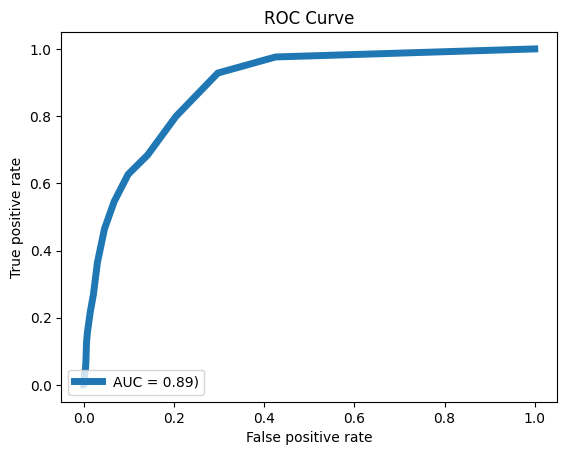

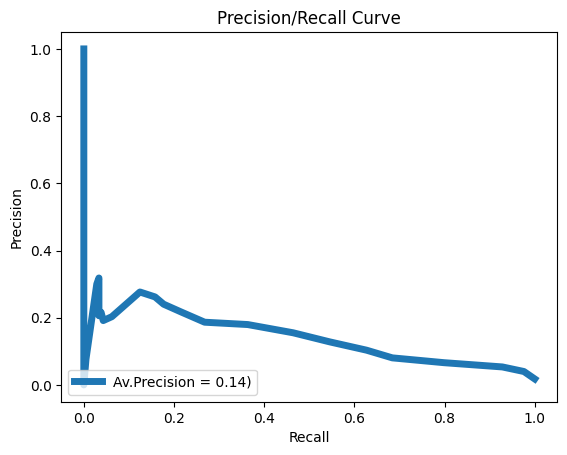

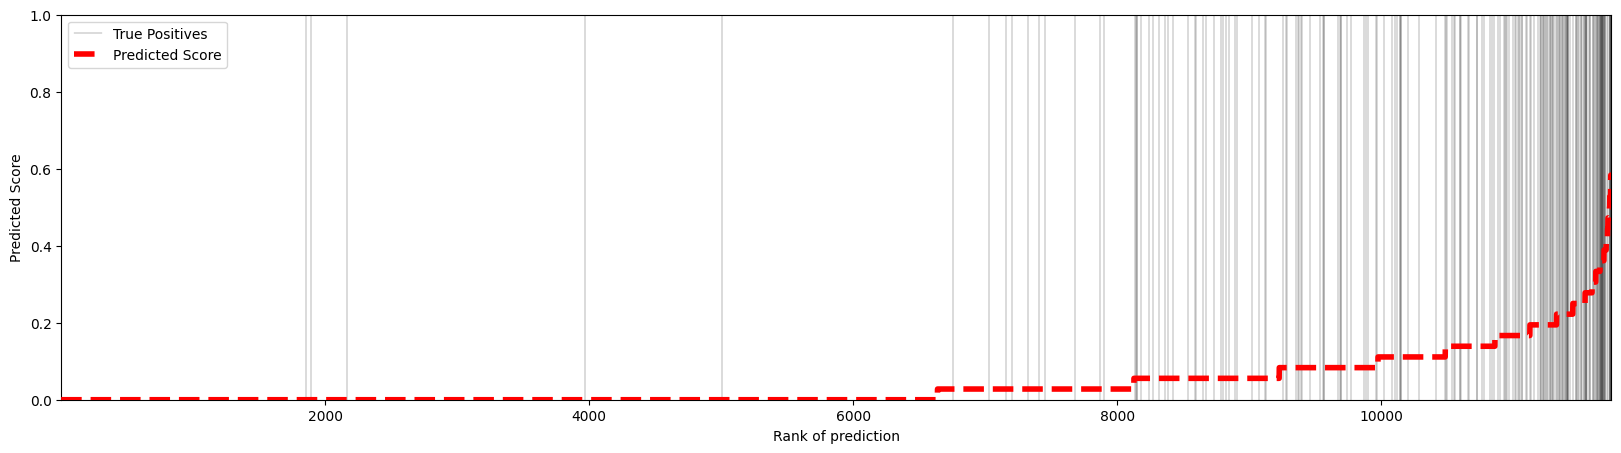

In [34]:
draw_roc_curve(labels_2, data_train['tourist_harm_2'],"dictionary_tourist_harm_precision_curve")

draw_precision_curve(labels_2, data_train['tourist_harm_2'],"dictionary_tourist_harm_precision_curve")

#Model critique



sep_data=data_train[["label_2",'tourist_harm_2']]
name=spitout + "separation_plot_dictionary_tourism.pdf"
separation_plot(sep_data, name)